In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime

#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

LSTM

In [2]:
start = "2006-01-01"
end = datetime.date.today()

# Create synthetic portfolio dataset
ASSETS = [
    "AAPL",   # equity
    "MSFT",   # equity
    "SPY",    # equity index
    "TLT",    # bonds
    "IEF",    # bonds
    "GLD",    # gold
    "USO",    # oil
    "VNQ",    # REIT
    "QQQ",   # volatility index
    "DBC"     # commodities
]

def get_returns(assets, start, end):
    failed_tickers = []

    # Download data
    prices = yf.download(assets, start=start, end=end, group_by='ticker', auto_adjust=True)

    # Prepare adjusted close DataFrame
    adj_close = pd.DataFrame()

    if isinstance(prices.columns, pd.MultiIndex):
        # Multi-ticker download
        for ticker in assets:
            if ticker in prices.columns.get_level_values(0):
                adj_close[ticker] = prices[ticker]['Close']
            else:
                failed_tickers.append(ticker)
    else:
        # Single ticker
        ticker = assets[0] if isinstance(assets, list) else assets
        if 'Close' in prices.columns:
            adj_close[ticker] = prices['Close']
        else:
            print(ticker, " failed download")
            failed_tickers.append(ticker)

    # Compute log returns
    returns = np.log(adj_close / adj_close.shift(1))

    # Drop NaNs and inf values 
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    return returns, failed_tickers

In [3]:
# Generate LSTM dataset: synthetic portfolio
np.random.seed(4265)

def generate_sparse_weights(n_assets, k=10, alpha=0.3):
    weights = np.zeros(n_assets)
    # Pick k assets to have significant weight
    selected = np.random.choice(n_assets, k, replace=False)
    rand_weights = np.random.dirichlet([alpha]*k)
    weights[selected] = rand_weights

    # Give small random weight to other assets
    remaining_idx = [i for i in range(n_assets) if i not in selected]
    weights[remaining_idx] = np.random.dirichlet([0.05]*len(remaining_idx)) * 0.01  

    # Normalize weights
    weights /= weights.sum()
    return weights

def create_lstm_dataset(returns, n_portfolios=500, window=60, horizon=10):
    X = []
    y_vol = []
    y_dir = []

    for _ in range(n_portfolios):
        weights = generate_sparse_weights(returns.shape[1], k=10)

        port_returns = returns.values @ weights

        for i in range(0, len(port_returns) - window - horizon, window): 
            # Ensure no overlapping window for each portfolio weight generated
            past_window = port_returns[i:i+window]
            past_window = (past_window - np.mean(past_window)) / (np.std(past_window) + 1e-8)

            future_window = port_returns[i+window:i+window+horizon]

            # Ground truth future volatility
            future_vol = np.std(future_window) * np.sqrt(252)

            # Ground Truth portfolio future direction
            future_return = np.sum(future_window)
            threshold = 0.002 * np.sqrt(horizon)

            if future_return > threshold:
                direction = 1
            elif future_return < -threshold:
                direction = 0
            else:
                continue  # skip ambiguous samples

            X.append(past_window)
            y_vol.append(future_vol)
            y_dir.append(direction)
            
    X = np.array(X).reshape(-1, window, 1)
    y_vol = np.array(y_vol)
    y_dir = np.array(y_dir)

    return X, y_vol, y_dir

In [4]:
returns, prices = get_returns(ASSETS, start=start, end=end)

X, y_vol, y_dir = create_lstm_dataset(returns)

# Train-validation-test split: 80-10-10
n_samples = len(X)
train_end = int(0.8 * n_samples)
valid_end = int(0.9 * n_samples)

X_train, yv_train, yd_train = X[:train_end], y_vol[:train_end], y_dir[:train_end]
X_valid, yv_valid, yd_valid = X[train_end:valid_end], y_vol[train_end:valid_end], y_dir[train_end:valid_end]
X_test, yv_test, yd_test   = X[valid_end:], y_vol[valid_end:], y_dir[valid_end:]

[*********************100%***********************]  10 of 10 completed


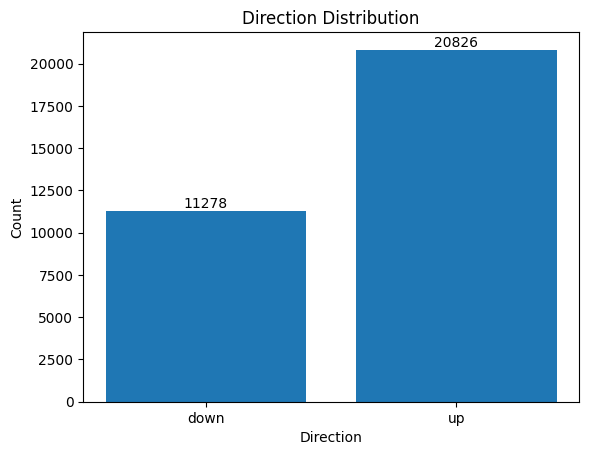

In [5]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(y_dir, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [6]:
# Undersample majority class
up_idx = np.where(yd_train == 1)[0]
down_idx = np.where(yd_train == 0)[0]

min_size = min(len(up_idx), len(down_idx))

up_sample = np.random.choice(up_idx, min_size, replace=False)
down_sample = np.random.choice(down_idx, min_size, replace=False)

balanced_idx = np.concatenate([up_sample, down_sample])
np.random.shuffle(balanced_idx)

X_train = X_train[balanced_idx]
yv_train = yv_train[balanced_idx]
yd_train = yd_train[balanced_idx]

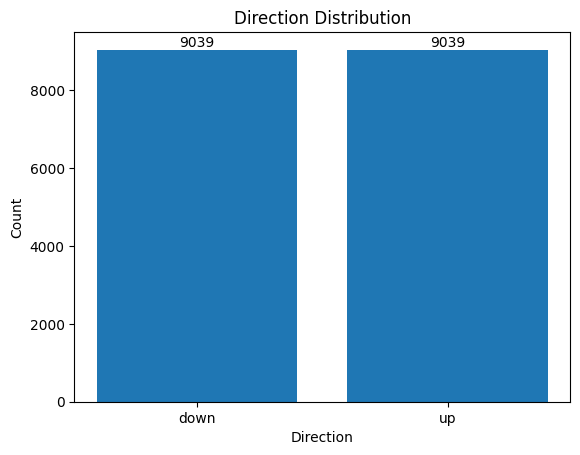

In [7]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(yd_train, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [8]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

yv_train = torch.tensor(yv_train, dtype=torch.float32).view(-1, 1)
yv_valid = torch.tensor(yv_valid, dtype=torch.float32).view(-1, 1)
yv_test  = torch.tensor(yv_test,  dtype=torch.float32).view(-1, 1)

yd_train = torch.tensor(yd_train, dtype=torch.float32).view(-1, 1)
yd_valid = torch.tensor(yd_valid, dtype=torch.float32).view(-1, 1)
yd_test  = torch.tensor(yd_test,  dtype=torch.float32).view(-1, 1)

class PortfolioDataset(Dataset):
    def __init__(self, X, y_vol, y_dir):
        self.X = X
        self.y_vol = y_vol
        self.y_dir = y_dir

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_vol[idx], self.y_dir[idx]


# Create Datasets
train_dataset = PortfolioDataset(X_train, yv_train, yd_train)
valid_dataset = PortfolioDataset(X_valid, yv_valid, yd_valid)
test_dataset = PortfolioDataset(X_test, yv_test, yd_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
print("Unique yd_train:", torch.unique(yd_train))
print("Sample yd_train:", yd_train[:10])

Unique yd_train: tensor([0., 1.])
Sample yd_train: tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.]])


In [10]:
# Regression loss
mse_loss = nn.MSELoss()

bce_loss = nn.BCEWithLogitsLoss()

In [11]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(LSTMModel, self).__init__()

        # LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)

        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        # Output heads
        self.volatility_head = nn.Linear(hidden_size2, 1)   # regression
        self.direction_head = nn.Sequential(
            nn.Linear(hidden_size2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )   # binary classification

    def forward(self, x):
        # x: (batch, seq_len, input_size)

        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        # Take last timestep
        out = out[:, -1, :]
        out = self.dropout2(out)

        vol_output = self.volatility_head(out)
        dir_output = self.direction_head(out)  

        return vol_output, dir_output

In [12]:
model = LSTMModel(input_size = X.shape[2])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

In [13]:
threshold = 0.5

In [14]:
all_preds = []
all_targets = []
all_probs = []

def evaluate(model, loader, mse_loss, bce_loss):
    model.eval()

    total_loss = 0
    total_vol_loss = 0
    total_dir_loss = 0
    total_mae = 0

    with torch.no_grad():
        for x, y_vol, y_dir in loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            
            vol_pred, dir_pred = model(x)
            #print("Logits std:", dir_pred.std().item())

            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            loss = 100 * loss_vol + 2 * loss_dir

            mae = torch.mean(torch.abs(vol_pred - y_vol))

            # Apply sigmoid before threshold
            probs = torch.sigmoid(dir_pred)
            preds = (probs > threshold).float()

            # check mean probs
            print("Mean prob:", probs.mean().item())
            print(probs.min().item(), probs.max().item())
            print("Predicted positives:", preds.sum().item())
            print("Actual positives:", y_dir.sum().item())

            all_preds.extend(dir_pred.view(-1).cpu().numpy())
            all_targets.extend(y_dir.view(-1).cpu().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())  

            total_loss += loss.item()
            total_vol_loss += loss_vol.item()
            total_dir_loss += loss_dir.item()
            total_mae += mae.item()

    auc = roc_auc_score(all_targets, all_probs)

    n = len(loader)
    return {
        "loss": total_loss / n,
        "vol_loss": total_vol_loss / n,
        "dir_loss": total_dir_loss / n,
        "mae": total_mae / n,
        "auc": auc,
    }

In [15]:
train_loss =  []
val_loss = []
train_vol_loss = []
val_vol_loss = []
train_dir_loss = [] 
val_dir_loss = []
train_mae = []
val_mae = []
train_auc = []
val_auc = []

def train(model, train_loader, val_loader, epochs, optimizer, mse_loss, bce_loss):
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 2
    trained_epochs = 0

    for epoch in range(epochs):
        model.train()

        for x, y_vol, y_dir in train_loader:
            optimizer.zero_grad()

            vol_pred, dir_pred = model(x)

            # Ensure shape consistency
            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            loss = 100 * loss_vol + 2 * loss_dir

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Evaluate
        train_metrics = evaluate(model, train_loader, mse_loss, bce_loss)
        val_metrics   = evaluate(model, val_loader, mse_loss, bce_loss)
        
        # For plots
        train_loss.append(train_metrics['loss'])
        val_loss.append(val_metrics['loss'])
        train_vol_loss.append(train_metrics['vol_loss'])
        val_vol_loss.append(val_metrics['vol_loss'])
        train_dir_loss.append(train_metrics['dir_loss'])
        val_dir_loss.append(val_metrics['dir_loss'])
        train_mae.append(train_metrics['mae'])
        val_mae.append(val_metrics['mae'])
        train_auc.append(train_metrics['auc'])
        val_auc.append(val_metrics['auc'])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train total Loss: {train_metrics['loss']:.4f} | Val total Loss: {val_metrics['loss']:.4f}")
        print(f"Train vol Loss: {train_metrics['vol_loss']:.4f} | Val vol Loss: {val_metrics['vol_loss']:.4f}")
        print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f}")

        trained_epochs += 1
        # Early stopping
        current_val_loss = val_metrics['loss']
        min_delta = 1e-4

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0

            # (optional) save best model
            best_model_state = model.state_dict()

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            EPOCHS = epoch+1
            break
    return trained_epochs, best_model_state

In [16]:
EPOCHS = 20
train(model, train_loader, val_loader, EPOCHS, optimizer, mse_loss, bce_loss)

# Save the model state_dict
torch.save(model.state_dict(), 'model_weights.pth')

Mean prob: 0.5028045177459717
0.49796009063720703 0.5089510679244995
Predicted positives: 55.0
Actual positives: 32.0
Mean prob: 0.5024579167366028
0.4989899694919586 0.5081907510757446
Predicted positives: 55.0
Actual positives: 30.0
Mean prob: 0.50227952003479
0.4969277083873749 0.5066567659378052
Predicted positives: 54.0
Actual positives: 34.0
Mean prob: 0.5029420852661133
0.4966626763343811 0.5083907246589661
Predicted positives: 59.0
Actual positives: 36.0
Mean prob: 0.5022981762886047
0.4969249665737152 0.5064188241958618
Predicted positives: 52.0
Actual positives: 36.0
Mean prob: 0.5028558969497681
0.49884822964668274 0.50698322057724
Predicted positives: 58.0
Actual positives: 35.0
Mean prob: 0.5027051568031311
0.4987386167049408 0.5088347792625427
Predicted positives: 55.0
Actual positives: 32.0
Mean prob: 0.5021541714668274
0.4977625906467438 0.5070850849151611
Predicted positives: 50.0
Actual positives: 30.0
Mean prob: 0.5029000043869019
0.4961441457271576 0.507498145103454

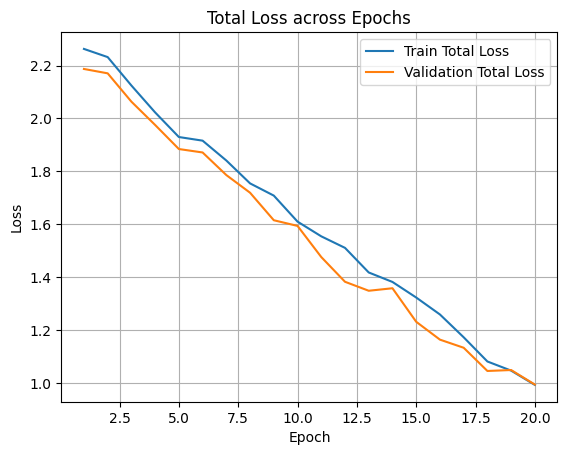

In [17]:
# Plot loss over epochs
plt.figure()
plt.plot(range(1, EPOCHS+1), train_loss, label='Train Total Loss')
plt.plot(range(1, EPOCHS+1), val_loss, label='Validation Total Loss')
plt.title('Total Loss across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

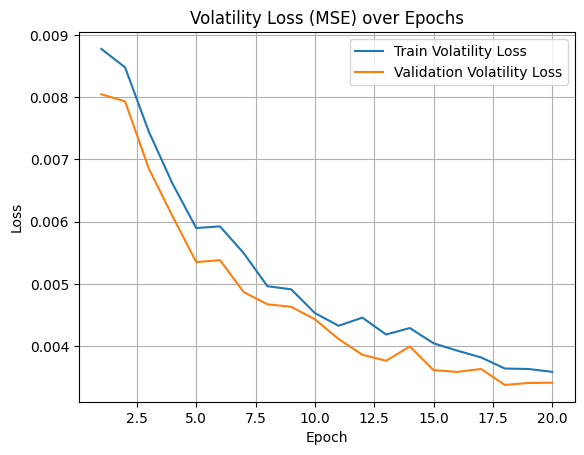

In [18]:
# Plot volatility MSE over epochs
plt.figure()
plt.plot(range(1, EPOCHS+1),train_vol_loss, label='Train Volatility Loss')
plt.plot(range(1, EPOCHS+1),val_vol_loss, label='Validation Volatility Loss')
plt.title('Volatility Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

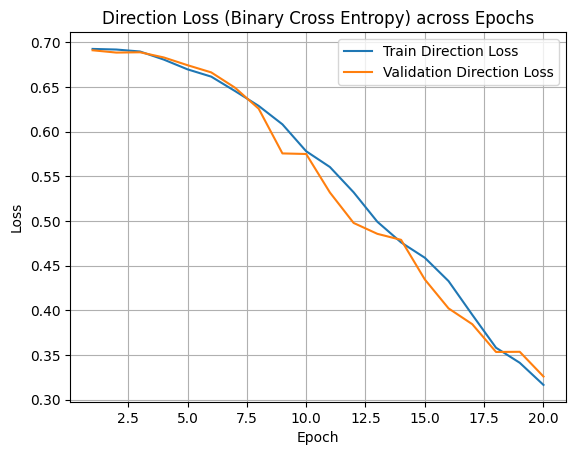

In [19]:
# PLot Binary Cross Entropy Loss
plt.figure()
plt.plot(range(1, EPOCHS+1),train_dir_loss, label='Train Direction Loss')
plt.plot(range(1, EPOCHS+1),val_dir_loss, label='Validation Direction Loss')
plt.title('Direction Loss (Binary Cross Entropy) across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

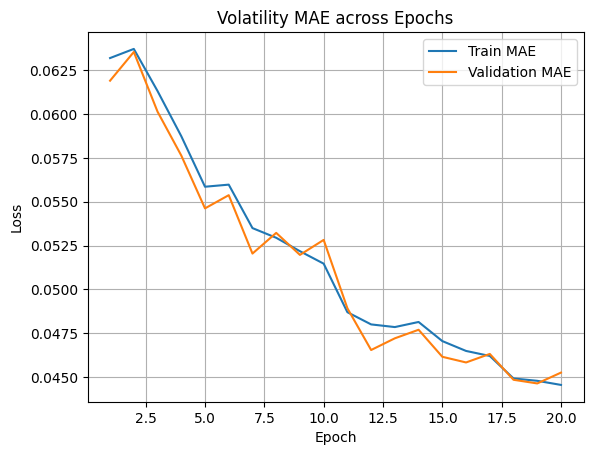

In [20]:
# PLot volatility MAE across epochs
plt.figure()
plt.plot(range(1, EPOCHS+1), train_mae, label='Train MAE')
plt.plot(range(1, EPOCHS+1), val_mae, label='Validation MAE')
plt.title('Volatility MAE across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


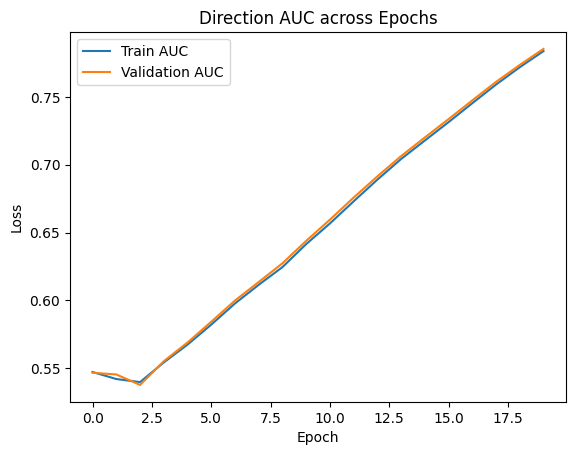

In [21]:
# Plot direction AUC across epochs 
plt.figure()
plt.plot(train_auc, label='Train AUC')
plt.plot(val_auc, label='Validation AUC')
plt.title('Direction AUC across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Future volatility of portfolio
def calculate_future_risk(model, tickers_weights_dictionary):
    X_input = portfolio_to_lstm_input(tickers_weights_dictionary)

    vol_pred, dir_pred = model.predict(X_input)

    vol = vol_pred[0][0]

    prob_up = dir_pred[0][0]

    direction = "Up" if prob_up > threshold else "Down"

    # Confidence = probability distance from 0.5
    confidence = abs(prob_up - threshold) * 2   # scaled to [0,1]

    return {
        "predicted_volatility": vol,
        "predicted_direction": direction,
        "confidence": confidence,
        "prob_up": prob_up
    }

In [23]:
all_preds = []
all_targets = []
all_probs = []
test_metrics = evaluate(model, test_loader, mse_loss, bce_loss)

Mean prob: 0.5572410225868225
0.005484250374138355 0.9659954905509949
Predicted positives: 38.0
Actual positives: 39.0
Mean prob: 0.6516968607902527
0.0026703733019530773 0.988766610622406
Predicted positives: 44.0
Actual positives: 47.0
Mean prob: 0.543337345123291
0.007658206857740879 0.975980818271637
Predicted positives: 35.0
Actual positives: 37.0
Mean prob: 0.6521828770637512
0.002022119704633951 0.9670529365539551
Predicted positives: 47.0
Actual positives: 47.0
Mean prob: 0.5591570138931274
0.0038372669368982315 0.968155562877655
Predicted positives: 38.0
Actual positives: 42.0
Mean prob: 0.5116946697235107
0.010389447212219238 0.9853213429450989
Predicted positives: 36.0
Actual positives: 33.0
Mean prob: 0.5728319883346558
0.0021969384979456663 0.977692186832428
Predicted positives: 39.0
Actual positives: 43.0
Mean prob: 0.5388774871826172
0.00518746767193079 0.9840803742408752
Predicted positives: 38.0
Actual positives: 42.0
Mean prob: 0.5906250476837158
0.005129242315888405 

In [24]:
print("Test set Volatility Evaluation:")
print(f"Test MSE: {test_metrics['vol_loss']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")

print("Test set Direction Evaluation:")
print(f"Test AUC: {test_metrics['auc']:.4f}")

Test set Volatility Evaluation:
Test MSE: 0.0037
Test MAE: 0.0451
Test set Direction Evaluation:
Test AUC: 0.9544


Confusion Matrix:
[[1019  103]
 [ 273 1816]]


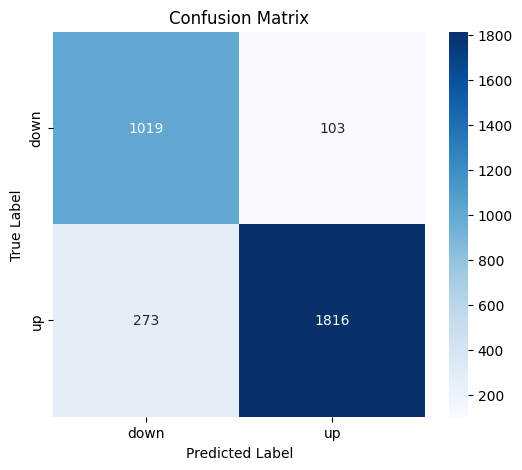

In [25]:
# Convert probabilities to 0/1
y_dir_pred_class = (np.array(all_preds) > threshold).astype(int)

# print(np.unique(yd_test))

# Confusion matrix
cm = confusion_matrix(yd_test, y_dir_pred_class)
print("Confusion Matrix:")
print(cm)

labels = ['down', 'up']
plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
   annot=True,
   fmt="d",
   cmap="Blues",
   xticklabels=labels,
   yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [26]:
# Classification Report

report = classification_report(yd_test, y_dir_pred_class, target_names=["Down", "Up"])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Down       0.79      0.91      0.84      1122
          Up       0.95      0.87      0.91      2089

    accuracy                           0.88      3211
   macro avg       0.87      0.89      0.88      3211
weighted avg       0.89      0.88      0.88      3211

